# Büyük Veri Güvenliği: UNSW-NB15 Ağ Trafiği Saldırı Tespiti
**Nesibe Şeyma CAN 255B7054**

**Ders:** Büyük Veri  
**Konu:** Ağ trafiği verilerinde makine öğrenimi ile saldırı tespiti ve etik değerlendirme  
**Veri Seti:** UNSW-NB15 (Australian Centre for Cyber Security - ACCS)  

---

## Proje Özeti

Bu çalışmada, büyük veri güvenliği kapsamında ağ trafiği verileri üzerinde saldırı tespiti modeli kurulmaktadır. Ağ trafiği verileri yüksek **hacim**, **hız** ve **çeşitlilik** içerdiği için büyük veri niteliği taşımaktadır. Model performansı teknik metriklerle değerlendirilirken, yanlış sınıflandırmaların doğurduğu güvenlik, etik ve mahremiyet riskleri de tartışılmaktadır.

## 1. Kütüphanelerin Yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme ve İlk İnceleme

In [2]:
train_df = pd.read_csv('data/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('data/UNSW_NB15_testing-set.csv')

print(f'Eğitim seti boyutu : {train_df.shape}')
print(f'Test seti boyutu   : {test_df.shape}')
print(f'\nÖzellik sayısı : {train_df.shape[1] - 2}  (id ve label hariç)')

Eğitim seti boyutu : (82332, 45)
Test seti boyutu   : (175341, 45)

Özellik sayısı : 43  (id ve label hariç)


In [3]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
print('--- Veri Türleri ---')
print(train_df.dtypes)
print('\n--- Eksik Değerler ---')
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

--- Veri Türleri ---
id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm            

## 3. Keşifsel Veri Analizi (EDA)

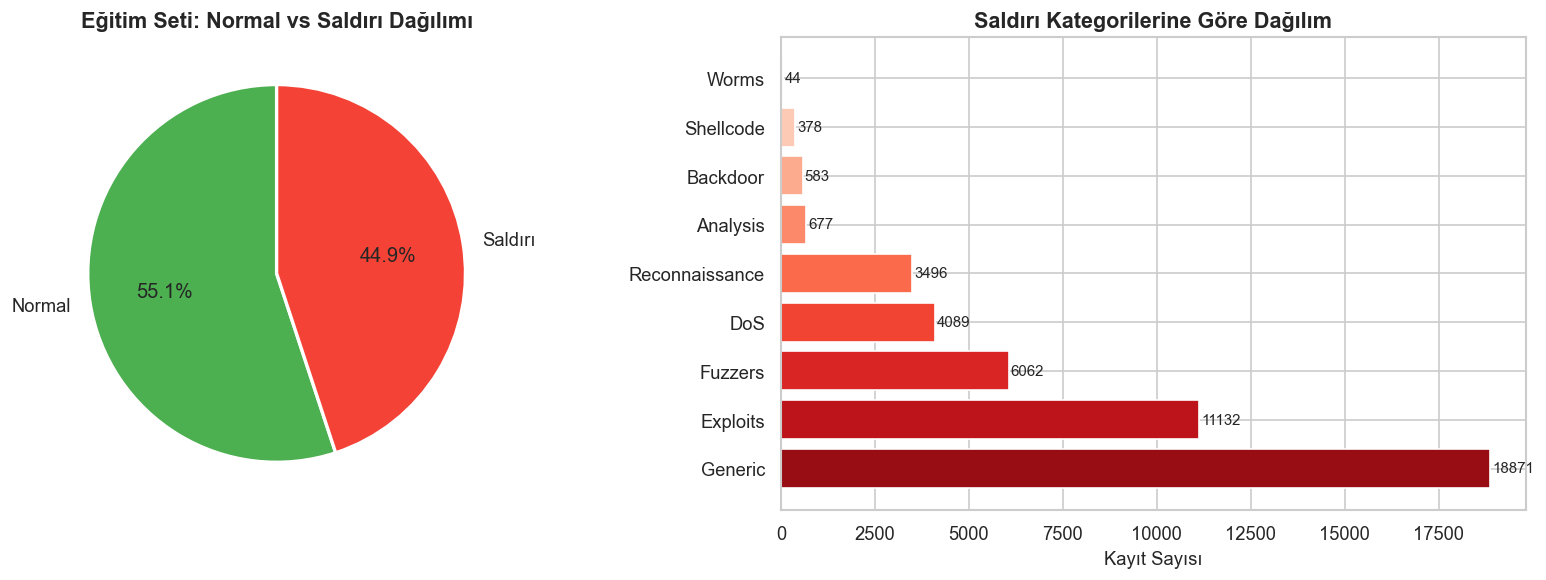


Eğitim: Normal=37000, Saldırı=45332
Saldırı oranı: %55.1


In [5]:
# Sınıf dağılımı - eğitim seti
label_counts = train_df['label'].value_counts()
attack_counts = train_df['attack_cat'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal vs Saldırı
axes[0].pie(label_counts, labels=['Normal', 'Saldırı'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Eğitim Seti: Normal vs Saldırı Dağılımı', fontsize=13, fontweight='bold')

# Saldırı kategorileri
attack_only = attack_counts[attack_counts.index != 'Normal']
colors_bar = sns.color_palette('Reds_r', len(attack_only))
axes[1].barh(attack_only.index, attack_only.values, color=colors_bar)
axes[1].set_xlabel('Kayıt Sayısı', fontsize=11)
axes[1].set_title('Saldırı Kategorilerine Göre Dağılım', fontsize=13, fontweight='bold')
for i, v in enumerate(attack_only.values):
    axes[1].text(v + 50, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nEğitim: Normal={label_counts[0]}, Saldırı={label_counts[1]}')
print(f'Saldırı oranı: %{label_counts[1]/label_counts.sum()*100:.1f}')

In [6]:
# Sayısal özellik istatistikleri
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'label']]
train_df[num_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
dur,82332.0,1.007000e+00,4.710000e+00,0.0,0.000,1.400000e-02,7.190000e-01,6.000000e+01
spkts,82332.0,1.866600e+01,1.339160e+02,1.0,2.000,6.000000e+00,1.200000e+01,1.064600e+04
dpkts,82332.0,1.754600e+01,1.155740e+02,0.0,0.000,2.000000e+00,1.000000e+01,1.101800e+04
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000,5.340000e+02,1.280000e+03,1.435577e+07
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000,1.780000e+02,9.560000e+02,1.465753e+07
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606,2.650177e+03,1.111111e+05,1.000000e+06
sttl,82332.0,1.809680e+02,1.015130e+02,0.0,62.000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,82332.0,9.571300e+01,1.166680e+02,0.0,0.000,2.900000e+01,2.520000e+02,2.530000e+02
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.467,5.770032e+05,6.514286e+07,5.268000e+09
dload,82332.0,6.305470e+05,2.393001e+06,0.0,0.000,2.112951e+03,1.585808e+04,2.082111e+07


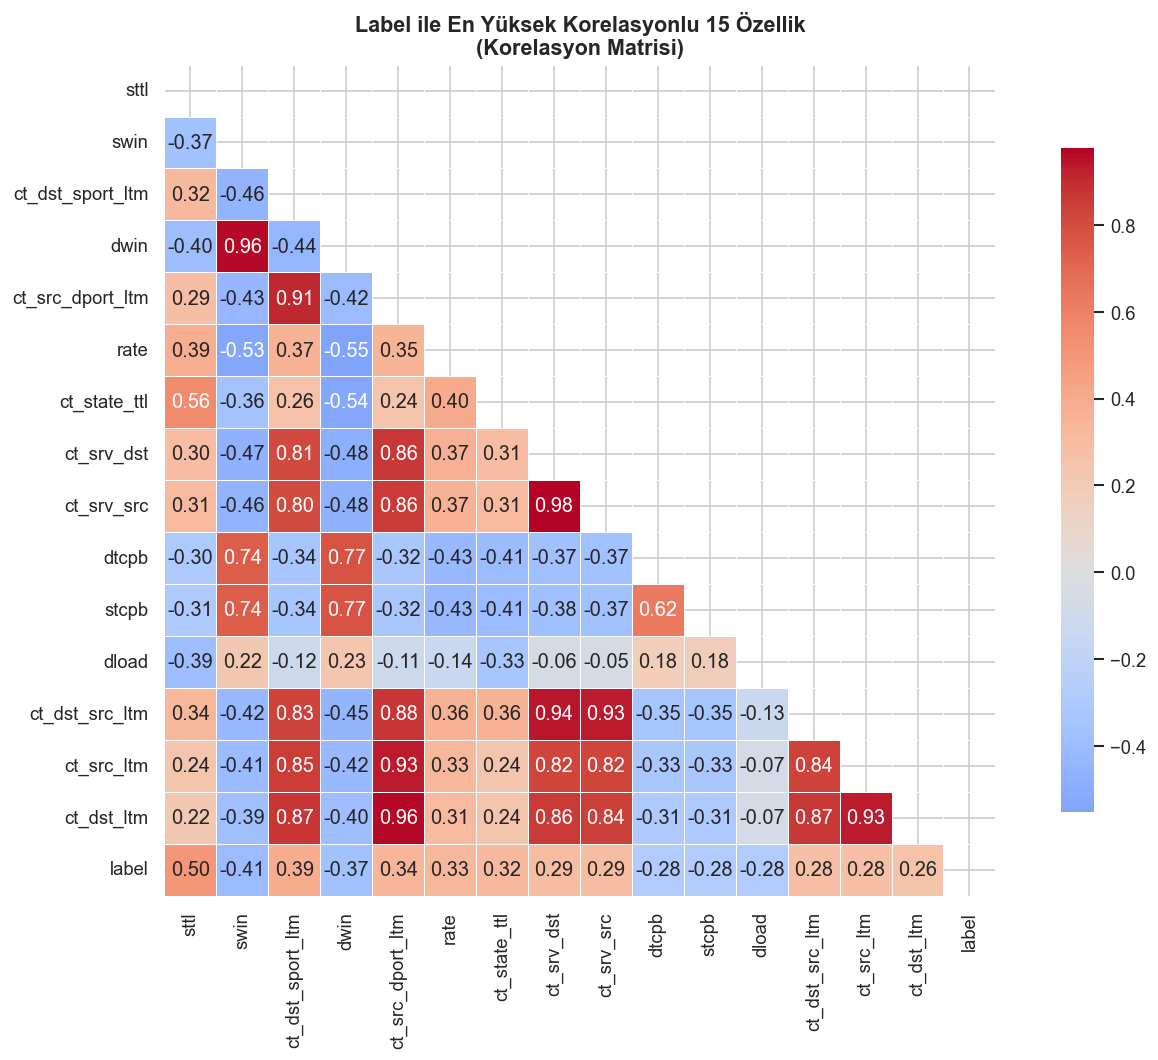

In [7]:
# Korelasyon ısı haritası (en çok değişen 15 özellik)
top_corr_cols = train_df[num_cols].corrwith(train_df['label']).abs().nlargest(15).index.tolist()
corr_matrix = train_df[top_corr_cols + ['label']].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Label ile En Yüksek Korelasyonlu 15 Özellik\n(Korelasyon Matrisi)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

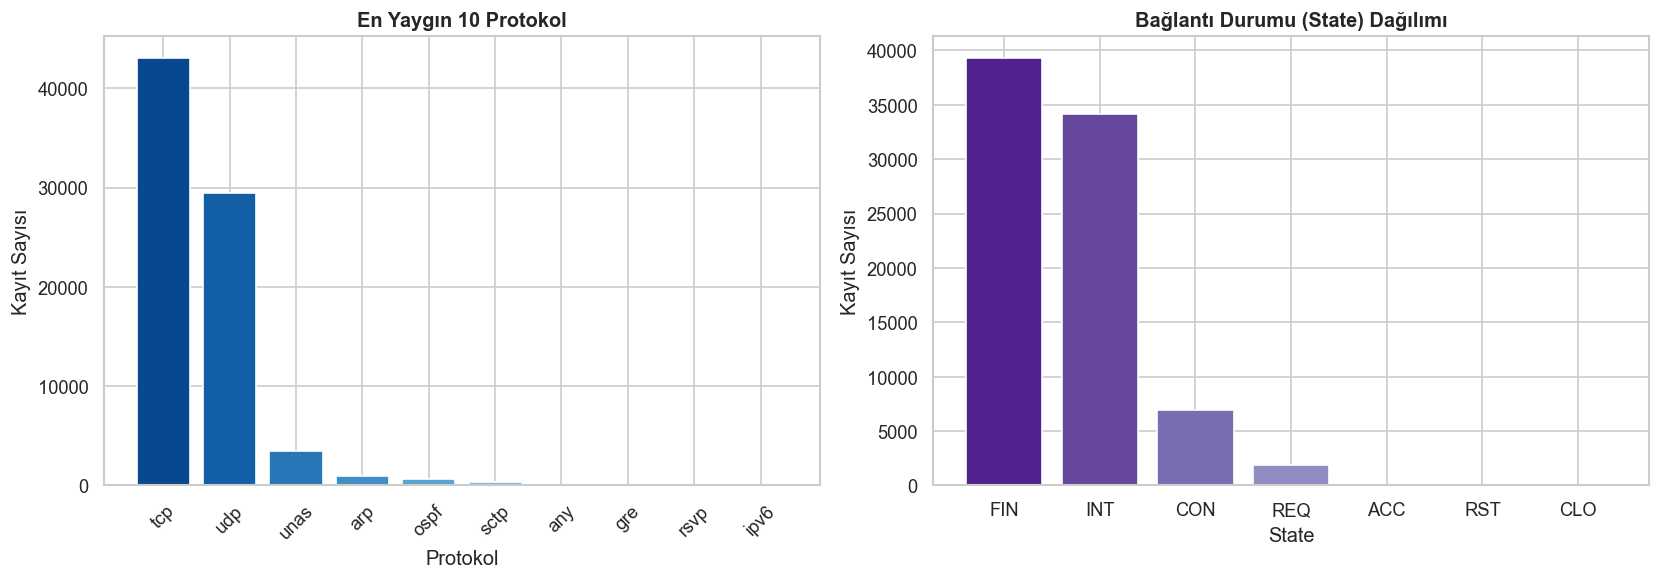

In [8]:
# Protokol dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

proto_counts = train_df['proto'].value_counts().head(10)
axes[0].bar(proto_counts.index, proto_counts.values, 
            color=sns.color_palette('Blues_r', 10))
axes[0].set_title('En Yaygın 10 Protokol', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Protokol')
axes[0].set_ylabel('Kayıt Sayısı')
axes[0].tick_params(axis='x', rotation=45)

# State dağılımı
state_counts = train_df['state'].value_counts().head(8)
axes[1].bar(state_counts.index, state_counts.values,
            color=sns.color_palette('Purples_r', 8))
axes[1].set_title('Bağlantı Durumu (State) Dağılımı', fontsize=12, fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Kayıt Sayısı')

plt.tight_layout()
plt.savefig('protocol_state.png', bbox_inches='tight')
plt.show()

## 4. Veri Ön İşleme (Preprocessing)

In [9]:
# Kategorik sütunlar
cat_cols = ['proto', 'service', 'state']
drop_cols = ['id', 'attack_cat']  # label tahmin hedefimiz, attack_cat ise kategorik etiket

def preprocess(df, encoders=None, fit=True):
    df = df.copy()
    df.drop(columns=drop_cols, inplace=True)
    
    if encoders is None:
        encoders = {}
    
    for col in cat_cols:
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        else:
            le = encoders[col]
            df[col] = df[col].astype(str).map(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    
    # Eksik değerleri medyan ile doldur
    df.fillna(df.median(numeric_only=True), inplace=True)
    return df, encoders

train_clean, encoders = preprocess(train_df, fit=True)
test_clean, _         = preprocess(test_df, encoders=encoders, fit=False)

print(f'Temizlenmiş eğitim seti: {train_clean.shape}')
print(f'Temizlenmiş test seti  : {test_clean.shape}')
train_clean.head(3)

Temizlenmiş eğitim seti: (82332, 43)
Temizlenmiş test seti  : (175341, 43)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.000011,117,0,4,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,117,0,4,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,117,0,4,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0


In [10]:
# Özellik / hedef ayrımı
X_train = train_clean.drop(columns=['label'])
y_train = train_clean['label']

X_test = test_clean.drop(columns=['label'])
y_test = test_clean['label']

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train_scaled.shape}, y_train dağılımı:')
print(y_train.value_counts().to_string())

X_train: (82332, 42), y_train dağılımı:
label
1    45332
0    37000


## 5. Model Eğitimi: Random Forest

In [11]:
# Sınıf dengesizliğine karşı ağırlıklandırma
class_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
cw_dict = {0: class_weights[0], 1: class_weights[1]}

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=cw_dict,
    random_state=42,
    n_jobs=-1
)

print('Model eğitiliyor...')
rf_model.fit(X_train_scaled, y_train)
print('Model eğitimi tamamlandı.')

Model eğitiliyor...
Model eğitimi tamamlandı.


## 6. Model Değerlendirmesi

In [12]:
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print('='*60)
print('         SINIFLANDIRMA RAPORU')
print('='*60)
print(classification_report(y_test, y_pred,
                             target_names=['Normal', 'Saldırı']))
print(f'ROC-AUC Skoru: {roc_auc_score(y_test, y_proba):.4f}')

         SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

      Normal       0.77      0.98      0.86     56000
     Saldırı       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341

ROC-AUC Skoru: 0.9864


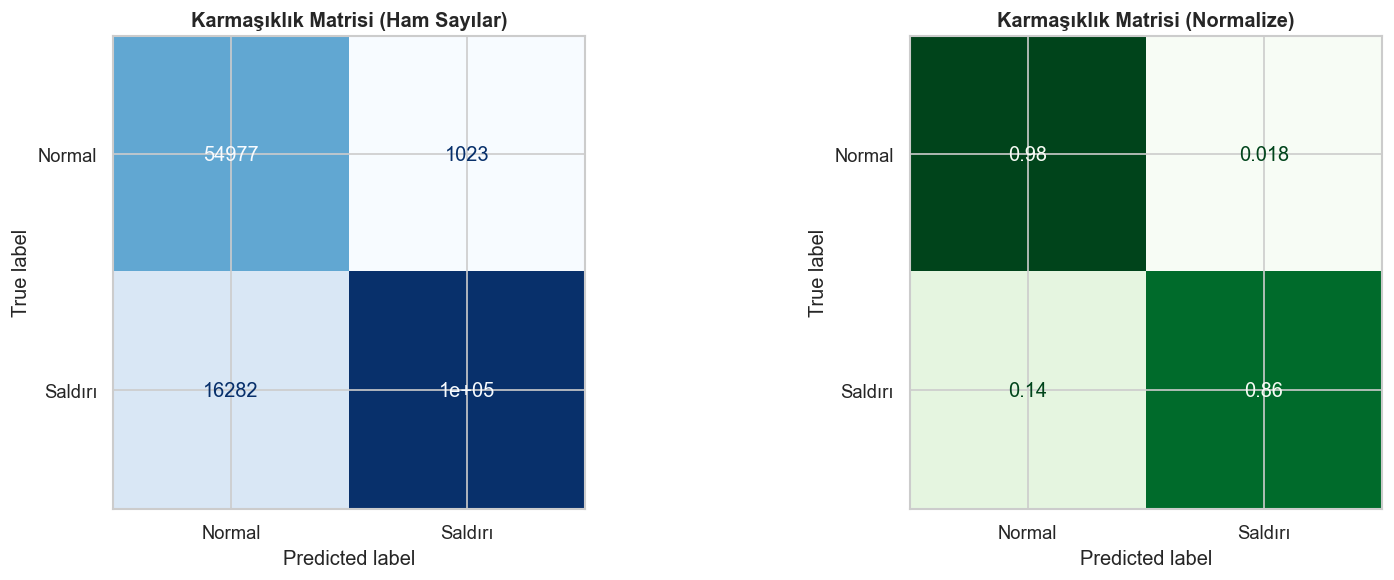


Gerçek Pozitif  (TP - Saldırı doğru tespit)  : 103,059
Yanlış Pozitif  (FP - Normal → Saldırı)      : 1,023
Yanlış Negatif  (FN - Saldırı → Normal)      : 16,282
Gerçek Negatif  (TN - Normal doğru tespit)   : 54,977


In [13]:
# Karmaşıklık matrisi
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ham sayılar
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Saldırı'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Karmaşıklık Matrisi (Ham Sayılar)', fontsize=12, fontweight='bold')

# Normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3),
                                display_labels=['Normal', 'Saldırı'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Karmaşıklık Matrisi (Normalize)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nGerçek Pozitif  (TP - Saldırı doğru tespit)  : {tp:,}')
print(f'Yanlış Pozitif  (FP - Normal → Saldırı)      : {fp:,}')
print(f'Yanlış Negatif  (FN - Saldırı → Normal)      : {fn:,}')
print(f'Gerçek Negatif  (TN - Normal doğru tespit)   : {tn:,}')

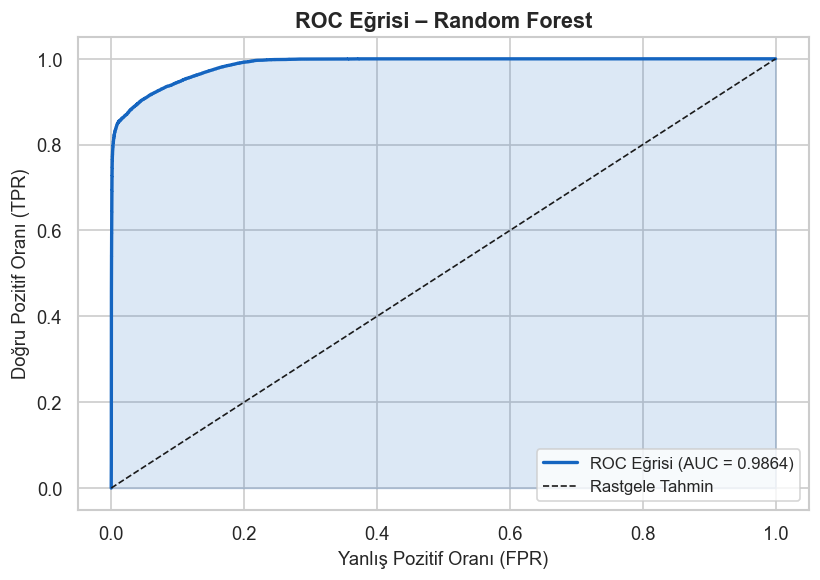

In [14]:
# ROC Eğrisi
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1565C0', lw=2,
         label=f'ROC Eğrisi (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Tahmin')
plt.fill_between(fpr, tpr, alpha=0.15, color='#1565C0')
plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=11)
plt.ylabel('Doğru Pozitif Oranı (TPR)', fontsize=11)
plt.title('ROC Eğrisi – Random Forest', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

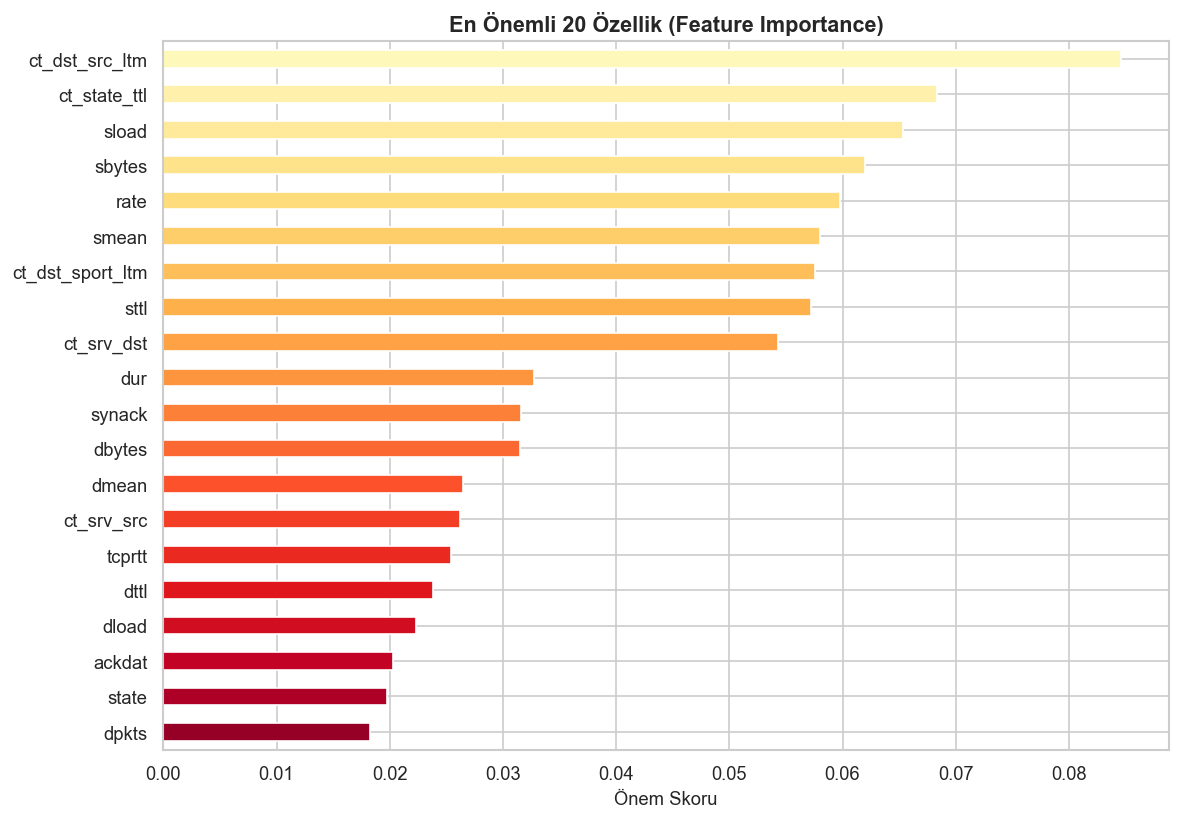


İlk 5 önemli özellik:
ct_dst_src_ltm    0.084590
ct_state_ttl      0.068383
sload             0.065361
sbytes            0.061973
rate              0.059811


In [15]:
# Özellik önemi
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 7))
colors = sns.color_palette('YlOrRd_r', 20)
top20.sort_values().plot(kind='barh', color=colors)
plt.xlabel('Önem Skoru', fontsize=11)
plt.title('En Önemli 20 Özellik (Feature Importance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('\nİlk 5 önemli özellik:')
print(top20.head().to_string())

## 7. Etik ve Mahremiyet Analizi

### 7.1 Yanlış Sınıflandırma Riskleri

In [16]:
# Yanlış sınıflandırma risk analizi
total_test = len(y_test)
fp_rate_pct = fp / (fp + tn) * 100
fn_rate_pct = fn / (fn + tp) * 100
recall_attack = tp / (tp + fn) * 100
precision_attack = tp / (tp + fp) * 100

risk_data = {
    'Metrik': ['Yanlış Pozitif (FP)', 'Yanlış Negatif (FN)', 
               'Recall (Saldırı Tespiti)', 'Precision (Hassasiyet)'],
    'Değer': [fp, fn, f'%{recall_attack:.2f}', f'%{precision_attack:.2f}'],
    'Risk Türü': ['Etik Risk: Masum kullanıcı tehdit olarak işaretlendi',
                  'Güvenlik Riski: Gerçek saldırı gözden kaçtı',
                  'Kaçırılan saldırı oranı ne kadar düşük?',
                  'Alarm ne kadar güvenilir?']
}

risk_df = pd.DataFrame(risk_data)
print('=== ETİK VE GÜVENLİK RİSK ÖZETİ ===')
print(risk_df.to_string(index=False))

=== ETİK VE GÜVENLİK RİSK ÖZETİ ===
                  Metrik  Değer                                            Risk Türü
     Yanlış Pozitif (FP)   1023 Etik Risk: Masum kullanıcı tehdit olarak işaretlendi
     Yanlış Negatif (FN)  16282          Güvenlik Riski: Gerçek saldırı gözden kaçtı
Recall (Saldırı Tespiti) %86.36              Kaçırılan saldırı oranı ne kadar düşük?
  Precision (Hassasiyet) %99.02                            Alarm ne kadar güvenilir?


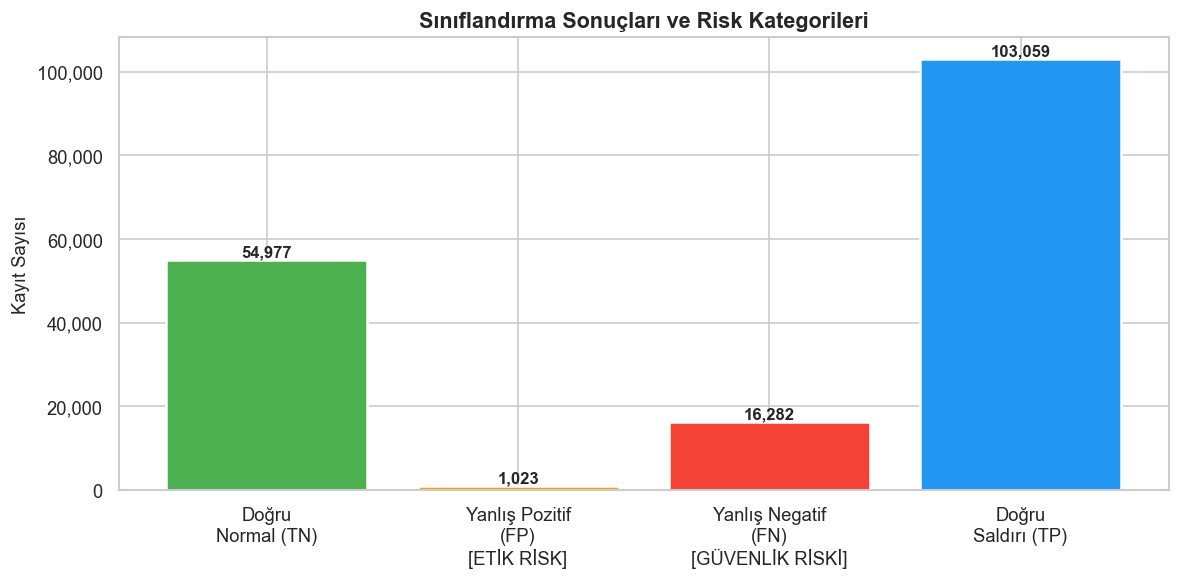

In [17]:
# Risk görselleştirmesi
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Doğru\nNormal (TN)', 'Yanlış Pozitif\n(FP)\n[ETİK RİSK]',
              'Yanlış Negatif\n(FN)\n[GÜVENLİK RİSKİ]', 'Doğru\nSaldırı (TP)']
values = [tn, fp, fn, tp]
bar_colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']

bars = ax.bar(categories, values, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Sınıflandırma Sonuçları ve Risk Kategorileri', fontsize=13, fontweight='bold')
ax.set_ylabel('Kayıt Sayısı', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('risk_analysis.png', bbox_inches='tight')
plt.show()

### 7.2 Mahremiyet ve GDPR Bağlantısı

In [18]:
# Mahremiyet riskli özellikler
privacy_features = {
    'Özellik': ['src_ip / dst_ip', 'sport / dport', 'stime / ltime',
                'proto', 'service', 'ct_src_ltm', 'ct_dst_ltm'],
    'Açıklama': ['Kaynak/Hedef IP adresi', 'Kaynak/Hedef port numarası',
                 'Bağlantı başlangıç/bitiş zamanı', 'Kullanılan protokol',
                 'Kullanılan servis (HTTP, FTP vb.)', 
                 'Kaynak IP son bağlantı sayısı',
                 'Hedef IP son bağlantı sayısı'],
    'GDPR Riski': ['YÜKSEK – Kişisel veri (tanımlayıcı)',
                   'ORTA – Dolaylı tanımlayıcı',
                   'ORTA – Davranış profili çıkarılabilir',
                   'DÜŞÜK', 'DÜŞÜK',
                   'ORTA – Bağlantı örüntüsü',
                   'ORTA – Bağlantı örüntüsü']
}

privacy_df = pd.DataFrame(privacy_features)
print('=== MAHREMİYET AÇISINDAN RİSKLİ ÖZELLİKLER ===')
print(privacy_df.to_string(index=False))

=== MAHREMİYET AÇISINDAN RİSKLİ ÖZELLİKLER ===
        Özellik                          Açıklama                            GDPR Riski
src_ip / dst_ip            Kaynak/Hedef IP adresi   YÜKSEK – Kişisel veri (tanımlayıcı)
  sport / dport        Kaynak/Hedef port numarası            ORTA – Dolaylı tanımlayıcı
  stime / ltime   Bağlantı başlangıç/bitiş zamanı ORTA – Davranış profili çıkarılabilir
          proto               Kullanılan protokol                                 DÜŞÜK
        service Kullanılan servis (HTTP, FTP vb.)                                 DÜŞÜK
     ct_src_ltm     Kaynak IP son bağlantı sayısı              ORTA – Bağlantı örüntüsü
     ct_dst_ltm      Hedef IP son bağlantı sayısı              ORTA – Bağlantı örüntüsü


## 8. Sonuç ve Değerlendirme

In [19]:
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print('='*60)
print('         PROJE SONUÇ ÖZETİ')
print('='*60)
print(f'  Model         : Random Forest (100 ağaç)')
print(f'  Doğruluk       : %{acc*100:.2f}')
print(f'  F1 Skoru       : {f1:.4f}')
print(f'  ROC-AUC        : {auc_score:.4f}')
print(f'  Yanlış Pozitif : {fp:,} (Etik Risk)')
print(f'  Yanlış Negatif : {fn:,} (Güvenlik Riski)')
print('='*60)
print()
print('ETİK DEĞERLENDİRME:')
print(f'  • {fp:,} normal kullanıcı yanlışlıkla saldırgan olarak işaretlendi.')
print(f'    → Haksız erişim engelleme ve mahremiyet ihlali riski.')
print(f'  • {fn:,} gerçek saldırı tespit edilemedi.')
print(f'    → Güvenlik açığı ve potansiyel sistem ihlali riski.')
print()
print('MAHREMİYET DEĞERLENDİRMESİ:')
print('  • IP adresleri ve bağlantı örüntüleri GDPR kapsamında')
print('    kişisel veri niteliği taşıyabilir.')
print('  • Veri minimizasyonu ilkesi uygulanmalıdır.')
print('  • İzleme orantılılık sınırları içinde kalmalıdır.')

         PROJE SONUÇ ÖZETİ
  Model         : Random Forest (100 ağaç)
  Doğruluk       : %90.13
  F1 Skoru       : 0.9225
  ROC-AUC        : 0.9864
  Yanlış Pozitif : 1,023 (Etik Risk)
  Yanlış Negatif : 16,282 (Güvenlik Riski)

ETİK DEĞERLENDİRME:
  • 1,023 normal kullanıcı yanlışlıkla saldırgan olarak işaretlendi.
    → Haksız erişim engelleme ve mahremiyet ihlali riski.
  • 16,282 gerçek saldırı tespit edilemedi.
    → Güvenlik açığı ve potansiyel sistem ihlali riski.

MAHREMİYET DEĞERLENDİRMESİ:
  • IP adresleri ve bağlantı örüntüleri GDPR kapsamında
    kişisel veri niteliği taşıyabilir.
  • Veri minimizasyonu ilkesi uygulanmalıdır.
  • İzleme orantılılık sınırları içinde kalmalıdır.
